# DFC CrossCoder — Experiments & Inspection

This notebook runs tests across both FineWeb (general text) and ToolRL (tool-use conversations).

**Prerequisites**
```bash
pip install torch transformers datasets wandb tqdm matplotlib
python run_cache.py   # extract + cache activations (~30 min)
python run_train.py   # train DFC from cache (~1-2 hrs)
```

---

## 0. Setup

In [2]:
import sys
sys.path.insert(0, '.')   # make sure local modules are importable

import torch
import matplotlib.pyplot as plt
import json
from pathlib import Path

from config import Config
from dfc import DFCCrossCoder
from cache import CachedActivationDataset, build_combined_dataset
from analysis import (
    inspect_latents,
    compare_on_texts,
    top_exclusive_features,
    decoder_similarity,
    feature_frequency,
    plot_loss,
)

cfg = Config()
DEVICE = cfg.train_device
print(f'Using device: {DEVICE}')
print(f'Cache: fineweb={cfg.fineweb_cache}  toolrl={cfg.toolrl_cache}')

Using device: cuda:0
Cache: fineweb=./cache/fineweb  toolrl=./cache/toolrl


## 1. Load Trained DFC

In [3]:
dfc = DFCCrossCoder.load(cfg.save_path, device=DEVICE)
dfc.eval()

print(f'  dict_size : {dfc.dict_size}')
print(f'  k         : {dfc.k}')
print(f'  n_a       : {dfc.n_a}  ({100*dfc.n_a/dfc.dict_size:.1f}%)')
print(f'  n_b       : {dfc.n_b}  ({100*dfc.n_b/dfc.dict_size:.1f}%)')
print(f'  n_shared  : {dfc.n_shared}  ({100*dfc.n_shared/dfc.dict_size:.1f}%)')

# Partition integrity sanity check
vi = dfc.verify_partition_integrity()
print(f'\nPartition integrity:')
print(f'  enc_max_violation = {vi["enc_max_violation"]:.2e}  (should be <1e-6)')
print(f'  dec_max_violation = {vi["dec_max_violation"]:.2e}  (should be <1e-6)')

[DFC] dict=16384 k=90 | A-excl=819 B-excl=819 shared=14746
  dict_size : 16384
  k         : 90
  n_a       : 819  (5.0%)
  n_b       : 819  (5.0%)
  n_shared  : 14746  (90.0%)

Partition integrity:
  enc_max_violation = 0.00e+00  (should be <1e-6)
  dec_max_violation = 0.00e+00  (should be <1e-6)


## 2. Load Datasets

In [4]:
fw_dataset  = CachedActivationDataset(cfg.fineweb_cache, normalize=True, source_label='fineweb')
tr_dataset  = CachedActivationDataset(cfg.toolrl_cache,  normalize=True, source_label='toolrl')
all_dataset = build_combined_dataset(cfg.fineweb_cache, cfg.toolrl_cache, normalize=True)

print(f'FineWeb : {len(fw_dataset):,} samples')
print(f'ToolRL  : {len(tr_dataset):,} samples')
print(f'Combined: {len(all_dataset):,} samples')

[Dataset] FineWeb: 15,000 | ToolRL: 15,000 | Total: 30,000
FineWeb : 15,000 samples
ToolRL  : 15,000 samples
Combined: 30,000 samples


## 3. Reconstruction Quality

In [5]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import random

def eval_reconstruction(dfc, dataset, n=512, batch_size=64, label=''):
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    sub  = Subset(dataset, idxs)
    loader = DataLoader(sub, batch_size=batch_size, shuffle=False)
    mses = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(DEVICE)
            recon, _ = dfc(batch)
            mse = F.mse_loss(recon, batch, reduction='none').mean(dim=(1,2))
            mses.append(mse.cpu())
    mses = torch.cat(mses)
    print(f'{label:12} MSE: mean={mses.mean():.5f}  std={mses.std():.5f}  median={mses.median():.5f}')
    return mses

mse_fw = eval_reconstruction(dfc, fw_dataset, label='FineWeb')
mse_tr = eval_reconstruction(dfc, tr_dataset, label='ToolRL')

FineWeb      MSE: mean=0.02562  std=0.01541  median=0.03152
ToolRL       MSE: mean=0.00890  std=0.00489  median=0.00752


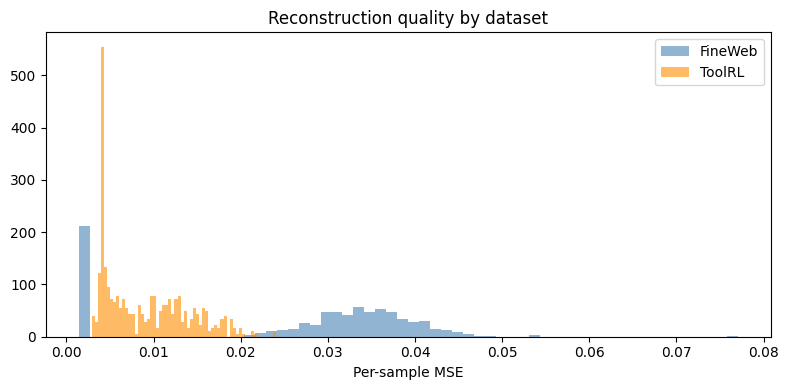

In [6]:
# MSE distribution comparison
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mse_fw.numpy(), bins=60, alpha=0.6, label='FineWeb', color='steelblue', density=True)
ax.hist(mse_tr.numpy(), bins=60, alpha=0.6, label='ToolRL',  color='darkorange', density=True)
ax.set_xlabel('Per-sample MSE')
ax.set_title('Reconstruction quality by dataset')
ax.legend()
plt.tight_layout()
plt.savefig('mse_distribution.png', dpi=120)
plt.show()

## 4. Feature Frequency by Partition

In [7]:
print('=== FineWeb ===')
freq_fw = feature_frequency(dfc, fw_dataset, n_samples=2048)

print('\n=== ToolRL ===')
freq_tr = feature_frequency(dfc, tr_dataset, n_samples=2048)

=== FineWeb ===



  Feature frequency over 2048 samples:
  A-exclusive : dead=624/819  max=579  mean=2.7
  B-exclusive : dead=585/819  max=70  mean=2.5
  Shared      : dead=2674/14746  max=1472  mean=12.2

=== ToolRL ===



  Feature frequency over 2048 samples:
  A-exclusive : dead=575/819  max=307  mean=4.3
  B-exclusive : dead=572/819  max=108  mean=3.7
  Shared      : dead=4631/14746  max=1742  mean=12.1


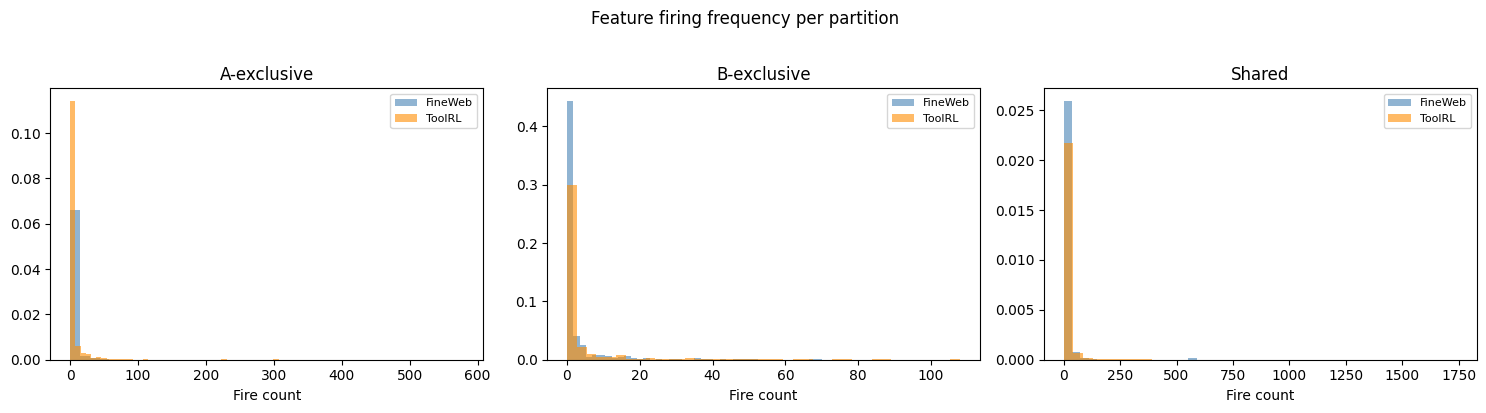

In [8]:
# Plot feature frequency spectrum per partition
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
partition_names = ['A-exclusive', 'B-exclusive', 'Shared']
slices = [
    (slice(None, dfc.a_end), slice(None, dfc.a_end)),
    (slice(dfc.a_end, dfc.b_end), slice(dfc.a_end, dfc.b_end)),
    (slice(dfc.b_end, None), slice(dfc.b_end, None)),
]

for ax, name, (sl_fw, sl_tr) in zip(axes, partition_names, slices):
    fw_vals = freq_fw[sl_fw].float().numpy()
    tr_vals = freq_tr[sl_tr].float().numpy()
    ax.hist(fw_vals, bins=40, alpha=0.6, label='FineWeb', color='steelblue', density=True)
    ax.hist(tr_vals, bins=40, alpha=0.6, label='ToolRL',  color='darkorange', density=True)
    ax.set_title(name)
    ax.set_xlabel('Fire count')
    ax.legend(fontsize=8)

plt.suptitle('Feature firing frequency per partition', y=1.02)
plt.tight_layout()
plt.savefig('feature_frequency.png', dpi=120)
plt.show()

## 5. Decoder Alignment (Shared Features)

In [9]:
cos = decoder_similarity(dfc)


══════════════════════════════════════════════════
  Shared-feature decoder cosine similarity  (n=14746)
══════════════════════════════════════════════════
  mean  : 0.9369
  std   : 0.0540
  min   : 0.2783
  max   : 0.9943
  >0.9  : 82.5%  (highly aligned)
  0.5–0.9: 17.3%  (partially aligned)
  <0.5  : 0.2%  (diverged)


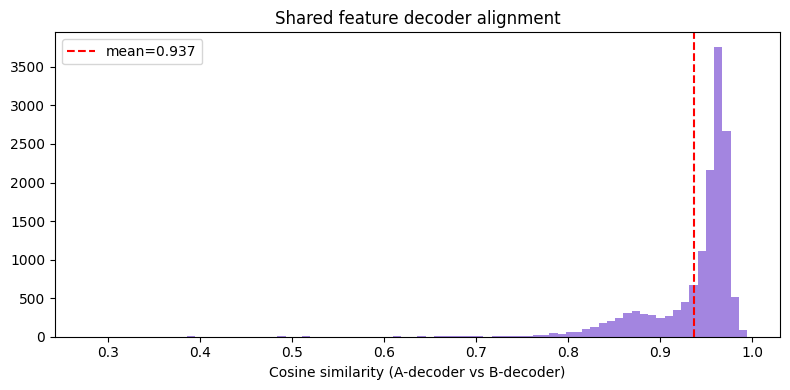

In [10]:
plt.figure(figsize=(8, 4))
plt.hist(cos.cpu().numpy(), bins=80, color='mediumpurple', edgecolor='none', alpha=0.85)
plt.axvline(cos.mean().item(), color='red', linestyle='--', label=f'mean={cos.mean():.3f}')
plt.xlabel('Cosine similarity (A-decoder vs B-decoder)')
plt.title('Shared feature decoder alignment')
plt.legend()
plt.tight_layout()
plt.savefig('decoder_similarity.png', dpi=120)
plt.show()

## 6. Qualitative Test — General Text vs Tool Use

In [11]:
# Sample random activations from each dataset and inspect partition breakdown
import random

def sample_and_inspect(dfc, dataset, n=5, label=''):
    print(f'\n{"="*60}')
    print(f'  {label}  —  {n} random samples')
    print(f'{"="*60}')
    idxs = random.sample(range(len(dataset)), n)
    rows = []
    with torch.no_grad():
        for i, idx in enumerate(idxs):
            x = dataset[idx].unsqueeze(0).to(DEVICE)   # (1, 2, d)
            recon, feats = dfc(x)
            f = feats[0].cpu()
            na = (f[:dfc.a_end] > 0).sum().item()
            nb = (f[dfc.a_end:dfc.b_end] > 0).sum().item()
            ns = (f[dfc.b_end:] > 0).sum().item()
            mse = F.mse_loss(recon[0].cpu(), x[0].cpu()).item()
            rows.append({'A-excl': na, 'B-excl': nb, 'Shared': ns, 'MSE': mse})
            print(f'  [{i}] A-excl={na:>3} | B-excl={nb:>3} | shared={ns:>4} | MSE={mse:.5f}')
    return rows

n_samples = 1000
fw_rows = sample_and_inspect(dfc, fw_dataset, n=n_samples, label='FineWeb (general text)')
tr_rows = sample_and_inspect(dfc, tr_dataset, n=n_samples, label='ToolRL  (tool use)')


  FineWeb (general text)  —  1000 random samples
  [0] A-excl=  1 | B-excl=  2 | shared=  87 | MSE=0.03320
  [1] A-excl=  1 | B-excl=  3 | shared=  86 | MSE=0.04093
  [2] A-excl=  0 | B-excl=  1 | shared=  89 | MSE=0.02893
  [3] A-excl=  0 | B-excl=  1 | shared=  89 | MSE=0.02692
  [4] A-excl=  2 | B-excl=  2 | shared=  86 | MSE=0.03572
  [5] A-excl=  0 | B-excl=  0 | shared=  90 | MSE=0.03448
  [6] A-excl=  1 | B-excl=  0 | shared=  89 | MSE=0.00144
  [7] A-excl=  0 | B-excl=  2 | shared=  88 | MSE=0.04363
  [8] A-excl=  1 | B-excl=  0 | shared=  89 | MSE=0.00144
  [9] A-excl=  0 | B-excl=  1 | shared=  89 | MSE=0.03940
  [10] A-excl=  1 | B-excl=  0 | shared=  89 | MSE=0.00144
  [11] A-excl=  0 | B-excl=  0 | shared=  90 | MSE=0.03080
  [12] A-excl=  1 | B-excl=  0 | shared=  89 | MSE=0.00144
  [13] A-excl=  2 | B-excl=  2 | shared=  86 | MSE=0.04251
  [14] A-excl=  1 | B-excl=  0 | shared=  89 | MSE=0.00144
  [15] A-excl=  0 | B-excl=  0 | shared=  90 | MSE=0.03637
  [16] A-excl=  

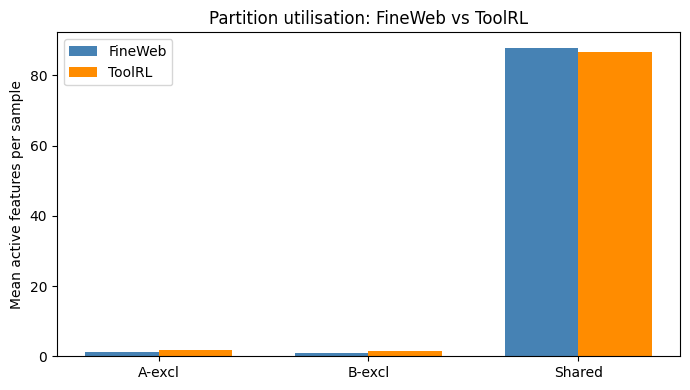

In [13]:
# Bar chart: mean partition activation counts FineWeb vs ToolRL
import numpy as np

keys = ['A-excl', 'B-excl', 'Shared']
fw_means = [np.mean([r[k] for r in fw_rows]) for k in keys]
tr_means = [np.mean([r[k] for r in tr_rows]) for k in keys]

x = np.arange(len(keys))
w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, fw_means, w, label='FineWeb', color='steelblue')
ax.bar(x + w/2, tr_means, w, label='ToolRL',  color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(keys)
ax.set_ylabel('Mean active features per sample')
ax.set_title('Partition utilisation: FineWeb vs ToolRL')
ax.legend()
plt.tight_layout()
plt.savefig('partition_utilisation.png', dpi=120)
plt.show()

## 7. Deep Dive — Inspect a Single Sample

In [16]:
# Pick a sample from ToolRL (index 0)
x = tr_dataset[3].to(DEVICE)
result = inspect_latents(dfc, x, top_n=30)


════════════════════════════════════════════════════════
  Latent Space Inspection
════════════════════════════════════════════════════════
  A-exclusive  active :     4 / 819    0.5%
  B-exclusive  active :     1 / 819    0.1%
  Shared       active :    85 / 14746  0.6%
  Total        active :    90 / 16384

     Feat      Value  Partition
  ───────────────────────────────────
     3147    14.6179  Shared
     2697    13.4847  Shared
    14607    10.2976  Shared
     3270    10.1867  Shared
     9198     8.7299  Shared
    13050     7.7400  Shared
    10194     7.1453  Shared
     5206     6.7213  Shared
    12635     5.6652  Shared
     4914     5.4668  Shared
     7090     5.2659  Shared
    11109     5.2266  Shared
     9007     5.1902  Shared
     1878     4.8124  Shared
     4544     4.6025  Shared
     5320     4.5536  Shared
     2364     4.4599  Shared
     5397     4.2372  Shared
     6428     4.2140  Shared
     7237     4.1155  Shared
     6568     4.0967  Shared
    11731

In [17]:
# Top A-exclusive features (Model A = ToolRL fine-tune)
top_exclusive_features(dfc, x, model='a', top_n=50)


  Top 4 Model-A exclusive features  (of 4 active):
     Feat      Value
      132     1.2814
      120     1.0763
      651     0.8960
      101     0.7703


[(132, 1.281449794769287),
 (120, 1.0762661695480347),
 (651, 0.8959563970565796),
 (101, 0.7703380584716797)]

In [18]:
# Top B-exclusive features (Model B = base Qwen)
top_exclusive_features(dfc, x, model='b', top_n=15)


  Top 1 Model-B exclusive features  (of 1 active):
     Feat      Value
      974     3.5787


[(974, 3.578683614730835)]

## 8. Live Comparison on Custom Texts

> **Requires models loaded.** Uncomment the cell below if you have enough VRAM.

In [19]:
# Uncomment to run live on custom text
from models import load_both_models
model_a, model_b, tokenizer = load_both_models(cfg)

general_texts = [
    "The French Revolution began in 1789 with widespread social discontent.",
    "Photosynthesis converts sunlight into chemical energy stored in glucose.",
    "Shakespeare wrote 37 plays and 154 sonnets during his lifetime.",
    "The mitochondria is known as the powerhouse of the cell.",
    "Gravity pulls objects toward each other with a force proportional to their masses.",
]

tool_use_texts = [
    "Search for the cheapest flight from London to Tokyo departing next Friday.",
    "Call the weather API with location=Paris and return a 5-day forecast.",
    "Use the calculator tool to compute the compound interest on $10,000 at 5% over 10 years.",
    "Query the database: SELECT * FROM orders WHERE status='pending' LIMIT 20.",
    "Book a table for 4 at the nearest Italian restaurant for Saturday 8pm.",
]

print('\n=== General Text ===')
feats_g, recon_g = compare_on_texts(
    dfc, model_a, model_b, tokenizer,
    general_texts, cfg.layer, cfg.device_a, cfg.device_b,
)

print('\n=== Tool-Use Text ===')
feats_t, recon_t = compare_on_texts(
    dfc, model_a, model_b, tokenizer,
    tool_use_texts, cfg.layer, cfg.device_a, cfg.device_b,
)

/home/cs29824/miniconda3/envs/dfc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading tokenizer from Qwen/Qwen2.5-3B ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading Model A (ToolRL): chengq9/ToolRL-Qwen2.5-3B → cuda:0


Loading weights: 100%|██████████| 435/435 [00:00<00:00, 1162.65it/s, Materializing param=model.norm.weight]                              
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

[Models] Loaded successfully. Activation dim: 2048

=== General Text ===


100%|██████████| 2/2 [00:00<00:00,  8.98it/s]



══════════════════════════════════════════════════════════════════════
  Model A (cuda:0) vs Model B (cuda:1)  |  layer 13  |  5 samples
══════════════════════════════════════════════════════════════════════

  [00] 'The French Revolution began in 1789 with widespread social discontent.'
        A-excl=  0 | B-excl=  0 | shared=  90 | MSE=2.02805

  [01] 'Photosynthesis converts sunlight into chemical energy stored in glucose.'
        A-excl=  0 | B-excl=  1 | shared=  89 | MSE=2.44045

  [02] 'Shakespeare wrote 37 plays and 154 sonnets during his lifetime.'
        A-excl=  2 | B-excl=  1 | shared=  87 | MSE=1.55422

  [03] 'The mitochondria is known as the powerhouse of the cell.'
        A-excl=  0 | B-excl=  0 | shared=  90 | MSE=1.70382

  [04] 'Gravity pulls objects toward each other with a force proportional to their masse'
        A-excl=  2 | B-excl=  0 | shared=  88 | MSE=1.55729

=== Tool-Use Text ===


100%|██████████| 2/2 [00:00<00:00, 14.52it/s]


══════════════════════════════════════════════════════════════════════
  Model A (cuda:0) vs Model B (cuda:1)  |  layer 13  |  5 samples
══════════════════════════════════════════════════════════════════════

  [00] 'Search for the cheapest flight from London to Tokyo departing next Friday.'
        A-excl=  0 | B-excl=  0 | shared=  90 | MSE=56.90406

  [01] 'Call the weather API with location=Paris and return a 5-day forecast.'
        A-excl=  2 | B-excl=  0 | shared=  88 | MSE=1.71598

  [02] 'Use the calculator tool to compute the compound interest on $10,000 at 5% over 1'
        A-excl=  1 | B-excl=  0 | shared=  89 | MSE=1.41576

  [03] "Query the database: SELECT * FROM orders WHERE status='pending' LIMIT 20."
        A-excl=  1 | B-excl=  0 | shared=  89 | MSE=2.04916

  [04] 'Book a table for 4 at the nearest Italian restaurant for Saturday 8pm.'
        A-excl=  3 | B-excl=  1 | shared=  86 | MSE=1.49685


## 9. A-exclusive vs B-exclusive Firing Rate by Dataset

In [20]:
from torch.utils.data import DataLoader

def partition_firing_rate(dfc, dataset, n=1024, batch_size=64):
    """Mean L0 per partition across n samples."""
    idxs = random.sample(range(len(dataset)), min(n, len(dataset)))
    sub = Subset(dataset, idxs)
    loader = DataLoader(sub, batch_size=batch_size, shuffle=False)
    stats = {'a': [], 'b': [], 's': []}
    with torch.no_grad():
        for batch in loader:
            feats = dfc.encode(batch.to(DEVICE))
            stats['a'].append((feats[:, :dfc.a_end] > 0).float().sum(dim=1).cpu())
            stats['b'].append((feats[:, dfc.a_end:dfc.b_end] > 0).float().sum(dim=1).cpu())
            stats['s'].append((feats[:, dfc.b_end:] > 0).float().sum(dim=1).cpu())
    return {k: torch.cat(v) for k, v in stats.items()}

from torch.utils.data import Subset

fw_fire = partition_firing_rate(dfc, fw_dataset)
tr_fire = partition_firing_rate(dfc, tr_dataset)

print(f'FineWeb — A-excl: {fw_fire["a"].mean():.2f}  B-excl: {fw_fire["b"].mean():.2f}  Shared: {fw_fire["s"].mean():.2f}')
print(f'ToolRL  — A-excl: {tr_fire["a"].mean():.2f}  B-excl: {tr_fire["b"].mean():.2f}  Shared: {tr_fire["s"].mean():.2f}')

FineWeb — A-excl: 1.07  B-excl: 1.08  Shared: 87.84
ToolRL  — A-excl: 1.71  B-excl: 1.48  Shared: 86.81


/tmp/ipykernel_1591438/2192313237.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1591438/2192313237.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_1591438/2192313237.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


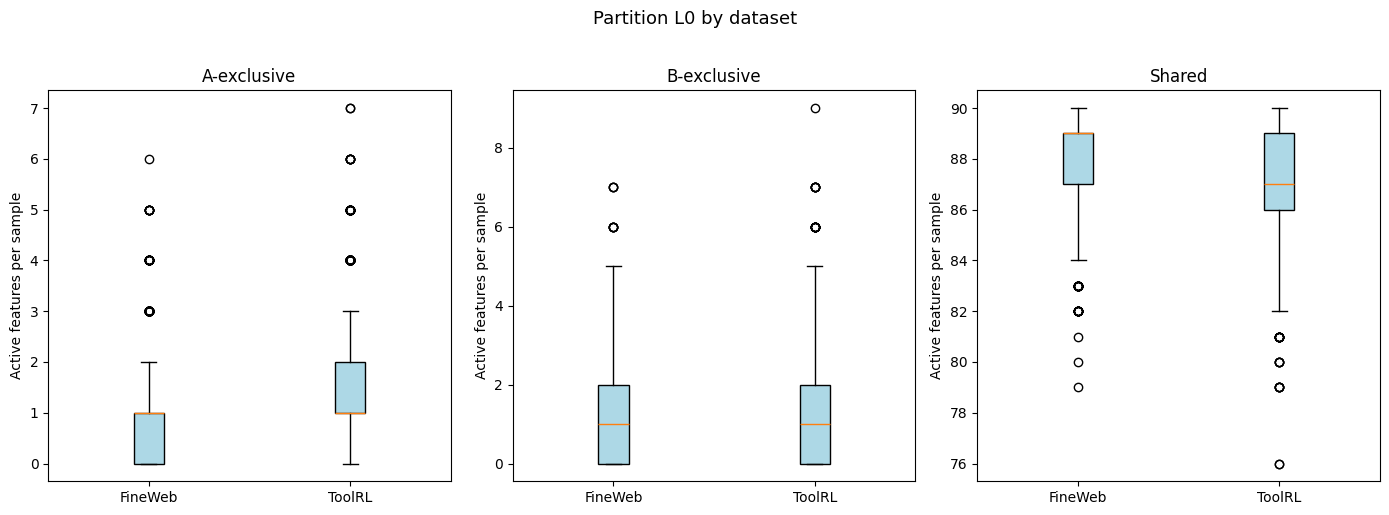

In [21]:
# Box plot of firing rates
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, key, label in zip(axes, ['a', 'b', 's'], ['A-exclusive', 'B-exclusive', 'Shared']):
    ax.boxplot(
        [fw_fire[key].numpy(), tr_fire[key].numpy()],
        labels=['FineWeb', 'ToolRL'],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
    )
    ax.set_title(label)
    ax.set_ylabel('Active features per sample')

plt.suptitle('Partition L0 by dataset', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('partition_l0_boxplot.png', dpi=120)
plt.show()

## 10. Most Differentiating Features

Features that fire much more often on ToolRL than FineWeb in the A-exclusive partition suggest tool-use specific representations learned by the fine-tuned model.

In [22]:
# Differential feature frequency: ToolRL - FineWeb (normalised)
diff = freq_tr.float() / max(len(tr_dataset), 1) - freq_fw.float() / max(len(fw_dataset), 1)

print('\n=== Top A-exclusive features more active on ToolRL ===')
a_diff = diff[:dfc.a_end]
topk_v, topk_i = torch.topk(a_diff, 15)
print(f'  {"Feat":>7}  {"ToolRL freq":>12}  {"FW freq":>10}  {"Δ":>8}')
for v, i in zip(topk_v.tolist(), topk_i.tolist()):
    fw_f = freq_fw[i].item()
    tr_f = freq_tr[i].item()
    print(f'  {i:>7}  {tr_f:>12}  {fw_f:>10}  {v:>8.4f}')

print('\n=== Top B-exclusive features more active on FineWeb ===')
b_diff = -diff[dfc.a_end:dfc.b_end]   # B-excl, flip sign to get FW > ToolRL
topk_v, topk_i = torch.topk(b_diff, 15)
for v, i in zip(topk_v.tolist(), topk_i.tolist()):
    gi = dfc.a_end + i
    fw_f = freq_fw[gi].item()
    tr_f = freq_tr[gi].item()
    print(f'  {gi:>7}  {tr_f:>12}  {fw_f:>10}  {v:>8.4f}')


=== Top A-exclusive features more active on ToolRL ===
     Feat   ToolRL freq     FW freq         Δ
      651           227          63    0.0109
      120            91           9    0.0055
      665            78           0    0.0052
       59           115          38    0.0051
      652            72           1    0.0047
      507            52           0    0.0035
       93            63          16    0.0031
      280            45           0    0.0030
      171            70          27    0.0029
      289            43           4    0.0026
      267            38           0    0.0025
      713            37           0    0.0025
      194            52          18    0.0023
      145            55          24    0.0021
      404            77          48    0.0019

=== Top B-exclusive features more active on FineWeb ===
     1227            18          70    0.0035
     1118             1          49    0.0032
      826             4          35    0.0021
     1305    

# Autointerp